In [5]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
BASE_DIR = Path("../").resolve()
TRAIN_PATH = BASE_DIR / "data" / "cleaned" / "train.csv"
TEST_PATH = BASE_DIR / "data" / "cleaned" / "test.csv"
OUTPUT_DIR = BASE_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

load train/test

In [7]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

X_train = train_df["text"]
y_train = train_df["label"]
X_test = test_df["text"]
y_test = test_df["label"]

print(train_df.shape, test_df.shape)
print(y_train.value_counts())

(941932, 2) (235483, 2)
label
Negative    501710
Neutral     247255
Positive    192967
Name: count, dtype: int64


train best model again

In [8]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

normalized confusion matrix

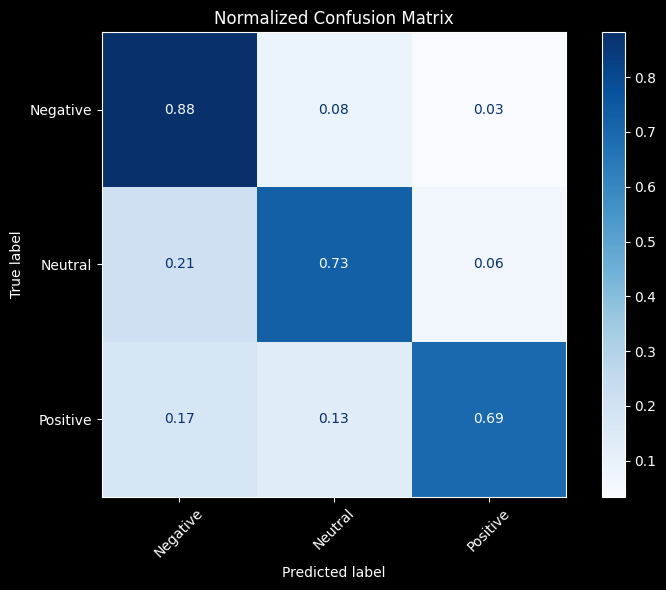

In [9]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "normalized_confusion_matrix.png", dpi=200)
plt.show()

top predictive words per class

In [10]:
feature_names = vectorizer.get_feature_names_out()
class_names = model.classes_

top_features = []

for i, class_name in enumerate(class_names):
    top_idx = np.argsort(model.coef_[i])[-15:]
    for idx in reversed(top_idx):
        top_features.append({
            "class": class_name,
            "feature": feature_names[idx],
            "weight": float(model.coef_[i][idx])
        })

top_features_df = pd.DataFrame(top_features)
top_features_df.to_csv(OUTPUT_DIR / "top_predictive_words.csv", index=False)

top_features_df.head(20)

,class,feature,weight
0,Negative,غزهتحتالقصف,10.198788
1,Negative,قصف,10.033990
2,Negative,قتل,7.443970
3,Negative,للاسف,6.767809
4,Negative,لعنه,6.692660
5,Negative,غزهتحتالقصفالقدستنتفض,6.562678
6,Negative,غزهمقبرهالغزاه,6.506402
7,Negative,جراء,6.454154
8,Negative,كذب,6.220361
9,Negative,دمر,6.216240


 top error pairs chart

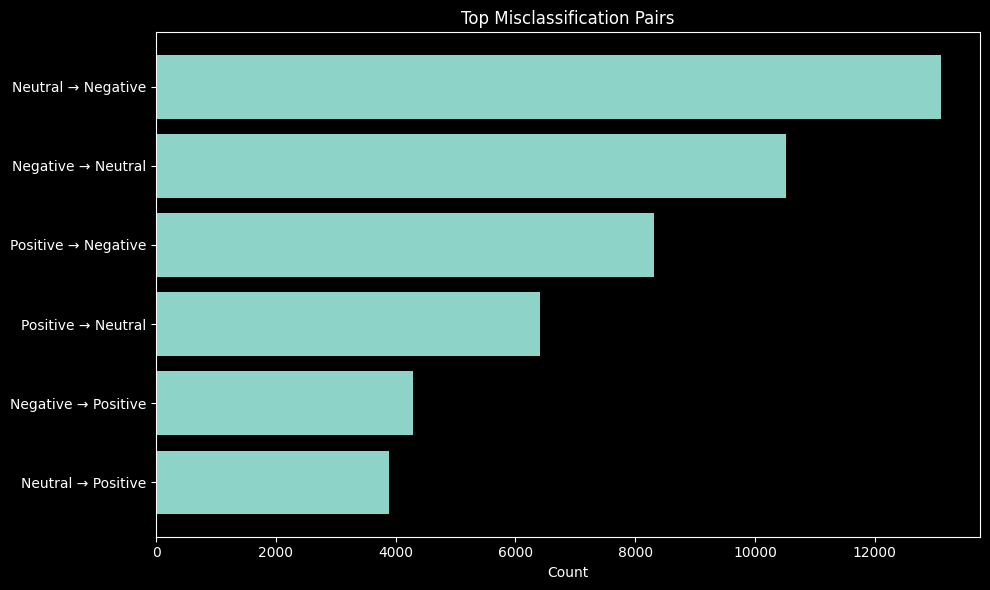

In [11]:
top_errors = pd.read_csv(OUTPUT_DIR / "top_error_pairs.csv")
top_errors["pair"] = top_errors["label"] + " → " + top_errors["predicted_label"]

top10 = top_errors.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["pair"], top10["count"])
plt.xlabel("Count")
plt.title("Top Misclassification Pairs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_error_pairs_chart.png", dpi=200)
plt.show()

model comparison chart

In [12]:
with open(OUTPUT_DIR / "metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": metrics["logistic_regression"]["accuracy"],
        "macro_f1": metrics["logistic_regression"]["macro_f1"]
    },
    {
        "model": "Linear SVM",
        "accuracy": metrics["linear_svm"]["accuracy"],
        "macro_f1": metrics["linear_svm"]["macro_f1"]
    }
])

results

,model,accuracy,macro_f1
0,Logistic Regression,0.802419,0.776697
1,Linear SVM,0.801039,0.775122


 plot model comparison

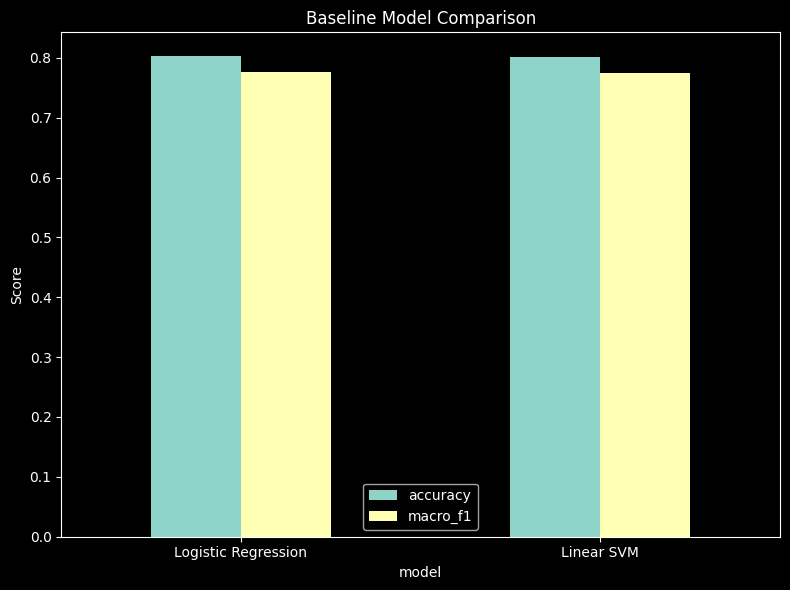

In [13]:
results.plot(x="model", y=["accuracy", "macro_f1"], kind="bar", figsize=(8, 6))
plt.ylabel("Score")
plt.title("Baseline Model Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=200)
plt.show()